# Notebook 1: Exploratory Data Analysis

## Project: Marketing Campaign Segmentation & ROI Analysis

**Dataset:** Pre-cleaned iFood Marketing Campaign Dataset
- 2,205 customers
- 39 columns
- CSV format (comma-separated)

**Objective:** Load the pre-cleaned marketing data, validate data quality, engineer derived features, and conduct comprehensive exploratory data analysis to uncover customer segments and campaign performance patterns.

**Author:** Stephen Drani

**Date:** March 2026

## 1.1 Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 
import warnings


# Set visualization style and parameters
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Load the Dataset

In [2]:
# Load the pre-cleaned iFood marketing dataset
df = pd.read_csv('../data/raw/archive/ifood_df.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

Dataset shape: (2205, 39)

First 5 rows:
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_Wido

## 1.3 Data Quality Validation

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
if missing_values.sum() == 0:
    print("✓ No missing values detected!")
else:
    print(missing_values[missing_values > 0])

print("\n" + "="*60)
print("Dataset Summary:")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*60)
print("Data Types:")
print("="*60)
print(df.dtypes)

Missing values per column:
✓ No missing values detected!

Dataset Summary:
Shape: (2205, 39)
Columns: 39
Duplicate rows: 184
Memory usage: 0.66 MB

Data Types:
Income                  float64
Kidhome                   int64
Teenhome                  int64
Recency                   int64
MntWines                  int64
MntFruits                 int64
MntMeatProducts           int64
MntFishProducts           int64
MntSweetProducts          int64
MntGoldProds              int64
NumDealsPurchases         int64
NumWebPurchases           int64
NumCatalogPurchases       int64
NumStorePurchases         int64
NumWebVisitsMonth         int64
AcceptedCmp3              int64
AcceptedCmp4              int64
AcceptedCmp5              int64
AcceptedCmp1              int64
AcceptedCmp2              int64
Complain                  int64
Z_CostContact             int64
Z_Revenue                 int64
Response                  int64
Age                       int64
Customer_Days             int64
marital_

## 1.4 Feature Engineering

In [21]:
# Create a working copy
df_enriched = df.copy()

# 1. Create 'Children' column (sum of Kidhome and Teenhome)
df_enriched['Children'] = df_enriched['Kidhome'] + df_enriched['Teenhome']

# 2. Create 'Total_Purchases' (sum across all purchase channels)
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
df_enriched['Total_Purchases'] = df_enriched[purchase_cols].sum(axis=1)

# 3. Create 'Total_Campaigns_Accepted' (sum of AcceptedCmp1-5)
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df_enriched['Total_Campaigns_Accepted'] = df_enriched[campaign_cols].sum(axis=1)

# 4. Create 'Conversion_Rate' (Total_Campaigns_Accepted / Total_Purchases, handle division by zero)
df_enriched['Conversion_Rate'] = np.divide(
    df_enriched['Total_Campaigns_Accepted'], 
    df_enriched['Total_Purchases'],
    where=df_enriched['Total_Purchases'] != 0,
    out=np.zeros_like(df_enriched['Total_Campaigns_Accepted'], dtype=float)
)

print("Feature engineering complete!")
print("\nNew features created:")
new_features = ['Children', 'Total_Purchases', 'Total_Campaigns_Accepted', 'Conversion_Rate']
print(df_enriched[new_features].head(10))

print(f"\nDataset shape after feature engineering: {df_enriched.shape}")
print(f"Total columns: {len(df_enriched.columns)}")

Feature engineering complete!

New features created:
   Children  Total_Purchases  Total_Campaigns_Accepted  Conversion_Rate
0         0               25                         0              0.0
1         2                6                         0              0.0
2         0               21                         0              0.0
3         1                8                         0              0.0
4         1               19                         0              0.0
5         1               22                         0              0.0
6         1               21                         0              0.0
7         1               10                         0              0.0
8         1                6                         0              0.0
9         2                2                         1              0.5

Dataset shape after feature engineering: (2205, 43)
Total columns: 43


## 1.5 Summary Statistics

In [22]:
# Summary statistics for key numeric columns
key_numeric_cols = ['Age', 'Income', 'MntTotal', 'MntRegularProds', 'Customer_Days', 
                    'Recency', 'Total_Purchases', 'Total_Campaigns_Accepted', 'Children',
                    'NumWebVisitsMonth']

print("="*80)
print("Summary Statistics of Key Numeric Columns")
print("="*80)
print(df_enriched[key_numeric_cols].describe())

print("\n" + "="*80)
print("Spending by Product Category (Mean)")
print("="*80)
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spending_summary = df_enriched[spending_cols].agg(['mean', 'median', 'sum']).round(2)
print(spending_summary)

Summary Statistics of Key Numeric Columns
               Age         Income     MntTotal  MntRegularProds  \
count  2205.000000    2205.000000  2205.000000      2205.000000   
mean     51.095692   51622.094785   562.764626       518.707483   
std      11.705801   20713.063826   575.936911       553.847248   
min      24.000000    1730.000000     4.000000      -283.000000   
25%      43.000000   35196.000000    56.000000        42.000000   
50%      50.000000   51287.000000   343.000000       288.000000   
75%      61.000000   68281.000000   964.000000       884.000000   
max      80.000000  113734.000000  2491.000000      2458.000000   

       Customer_Days      Recency  Total_Purchases  Total_Campaigns_Accepted  \
count    2205.000000  2205.000000      2205.000000                2205.00000   
mean     2512.718367    49.009070        14.887982                   0.29932   
std       202.563647    28.932111         7.615277                   0.68044   
min      2159.000000     0.000000 

## 1.6 Exploratory Data Analysis - Visualizations

### 1.6.1 Income Distribution

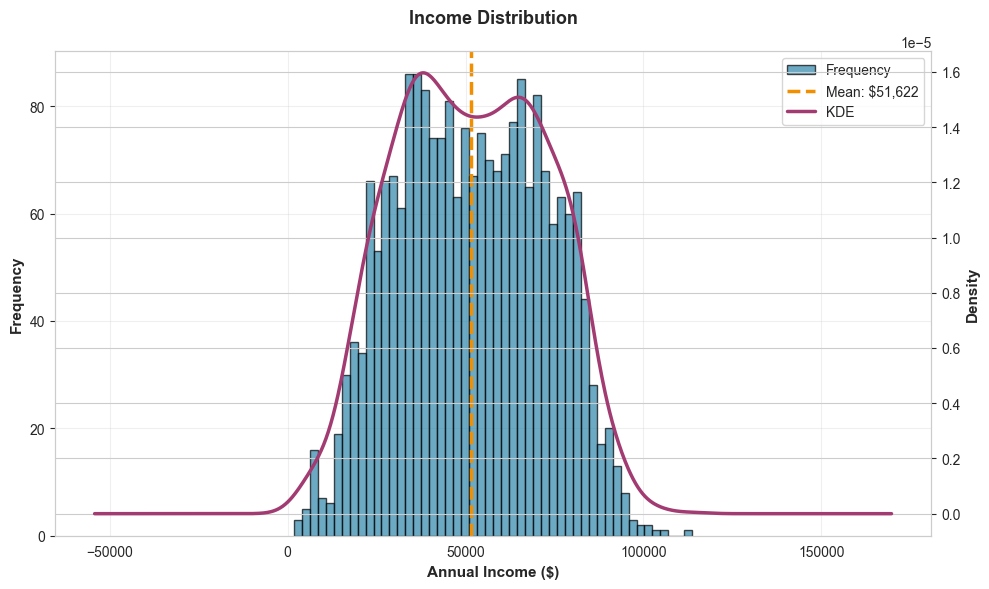

Income Statistics:
  Mean: $51,622.09
  Median: $51,287.00
  Std Dev: $20,713.06


In [23]:
# Create figure with income distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Ensure Income is numeric and drop missing values
income_series = pd.to_numeric(df_enriched['Income'], errors='coerce').dropna()
if income_series.empty:
    raise ValueError("No numeric values found in Income after conversion.")

# Histogram with KDE overlay
ax.hist(income_series, bins=50, color='#2E86AB', alpha=0.7, edgecolor='black', label='Frequency')
ax2 = ax.twinx()
income_series.plot(kind='kde', ax=ax2, color='#A23B72', linewidth=2.5, label='KDE')

# Add mean line
mean_income = income_series.mean()
ax.axvline(mean_income, color='#F18F01', linestyle='--', linewidth=2.5, label=f'Mean: ${mean_income:,.0f}')

ax.set_xlabel('Annual Income ($)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('Income Distribution', fontsize=13, fontweight='bold', pad=20)

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=10)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/01_income_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Income Statistics:")
print(f"  Mean: ${df_enriched['Income'].mean():,.2f}")
print(f"  Median: ${df_enriched['Income'].median():,.2f}")
print(f"  Std Dev: ${df_enriched['Income'].std():,.2f}")

### 1.6.2 Age Distribution

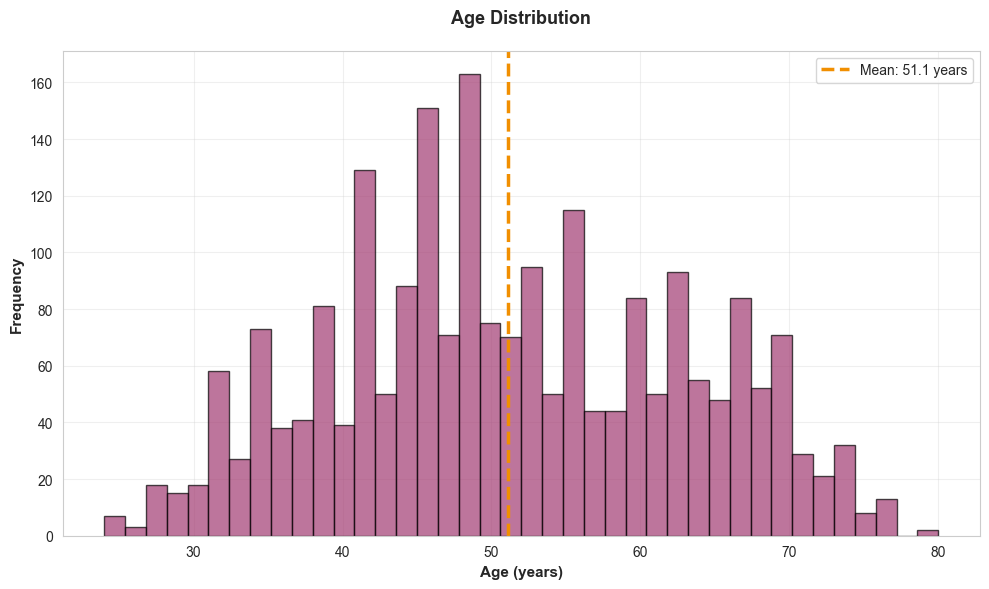

Age Statistics:
  Min: 24 years
  Max: 80 years
  Mean: 51.1 years
  Median: 50.0 years


In [24]:
# Create figure with age distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_enriched['Age'], bins=40, color='#A23B72', alpha=0.7, edgecolor='black')

# Add mean line
mean_age = df_enriched['Age'].mean()
ax.axvline(mean_age, color='#F18F01', linestyle='--', linewidth=2.5, label=f'Mean: {mean_age:.1f} years')

ax.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Age Distribution', fontsize=13, fontweight='bold', pad=20)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/02_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Age Statistics:")
print(f"  Min: {df_enriched['Age'].min()} years")
print(f"  Max: {df_enriched['Age'].max()} years")
print(f"  Mean: {df_enriched['Age'].mean():.1f} years")
print(f"  Median: {df_enriched['Age'].median():.1f} years")

### 1.6.3 Correlation Heatmap - Spending Columns

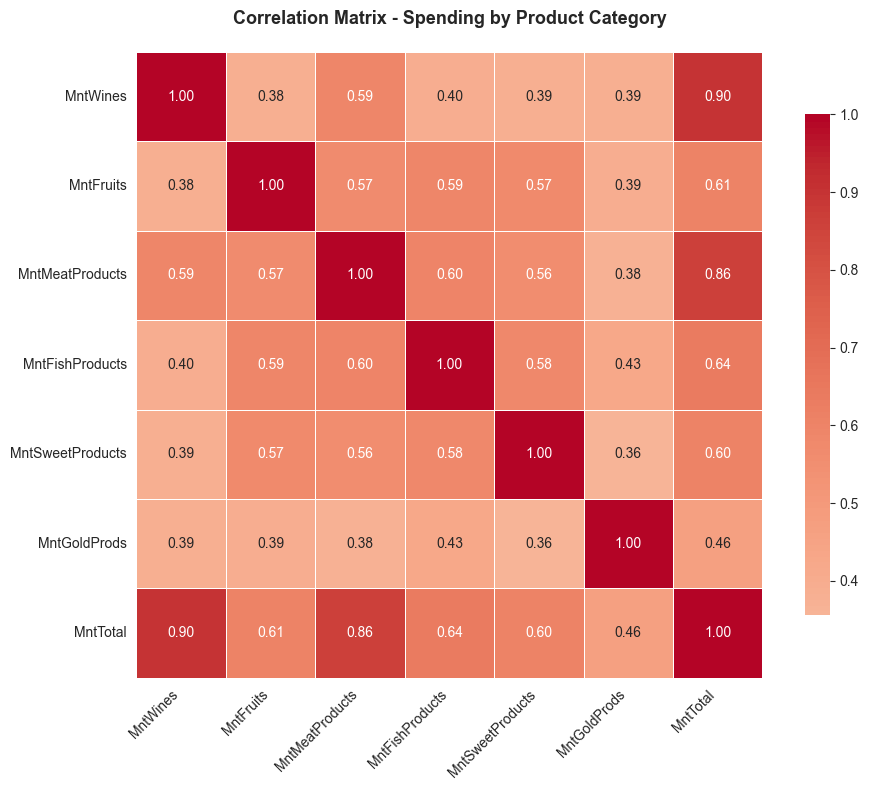

Top correlations with MntTotal:
  MntWines: 0.902
  MntMeatProducts: 0.861
  MntFishProducts: 0.635
  MntFruits: 0.607
  MntSweetProducts: 0.605
  MntGoldProds: 0.464


In [25]:
# Select spending columns for correlation analysis
spending_cols_corr = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'MntTotal']

# Create correlation matrix
corr_matrix = df_enriched[spending_cols_corr].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Correlation Matrix - Spending by Product Category', fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../visualizations/03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top correlations with MntTotal:")
correlations = corr_matrix['MntTotal'].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != 'MntTotal':
        print(f"  {feature}: {corr:.3f}")

### 1.6.4 Total Spending by Education Level

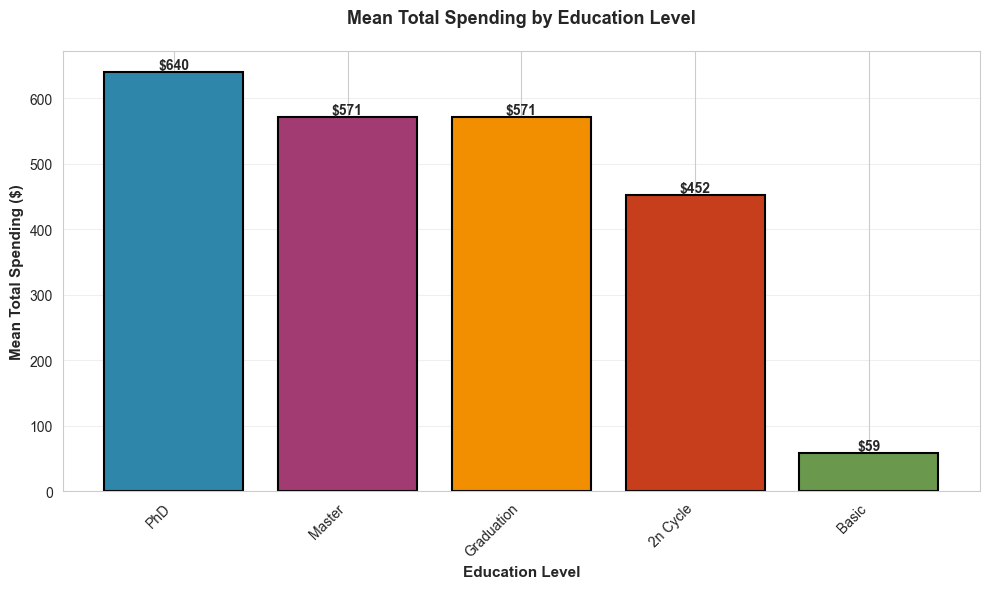

Spending by Education Level:
                       mean  median  count
Education_Label                           
PhD              640.466387   451.5    476
Master           571.002747   312.0    364
Graduation       570.938904   349.0   1113
2n Cycle         452.272727   180.0    198
Basic             58.962963    40.0     54


In [26]:
# Reconstruct education labels from one-hot encoding
education_cols = ['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']

# Create education label
def get_education_label(row):
    for col in education_cols:
        if col in df_enriched.columns and row[col] == 1:
            return col.replace('education_', '')
    return 'Unknown'

df_enriched['Education_Label'] = df_enriched.apply(get_education_label, axis=1)

# Group by education and calculate mean spending
education_spending = df_enriched.groupby('Education_Label')['MntTotal'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
bars = ax.bar(education_spending.index, education_spending['mean'], 
              color=colors[:len(education_spending)], edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Education Level', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Total Spending ($)', fontsize=11, fontweight='bold')
ax.set_title('Mean Total Spending by Education Level', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visualizations/04_spending_by_education.png', dpi=300, bbox_inches='tight')
plt.show()

print("Spending by Education Level:")
print(education_spending)

### 1.6.5 Spending by Product Category

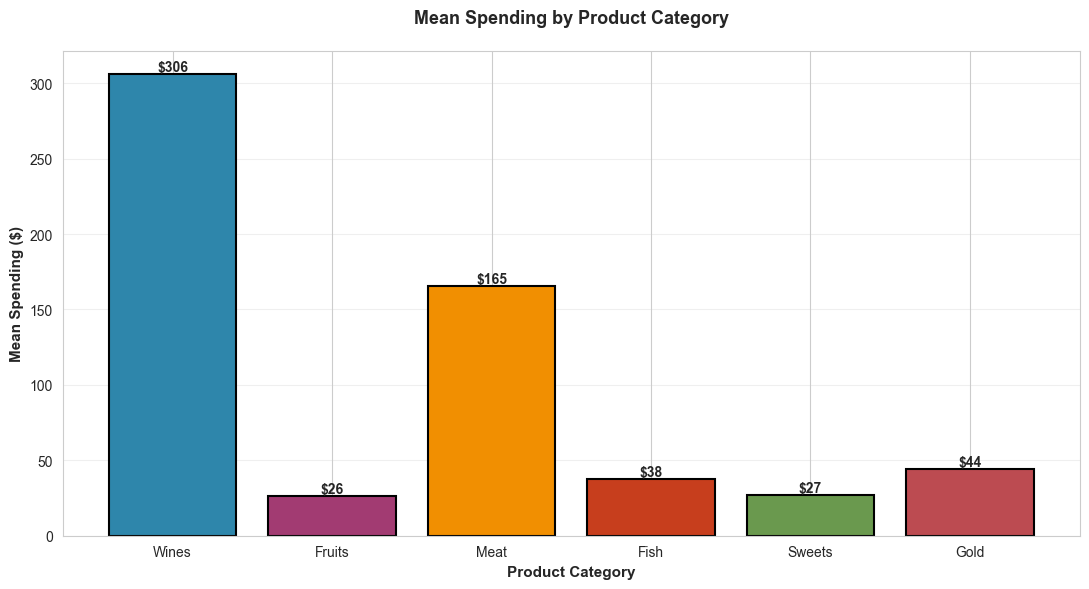

Mean Spending by Product Category:
  Wines: $306.16
  Meat: $165.31
  Gold: $44.06
  Fish: $37.76
  Sweets: $27.13
  Fruits: $26.40


In [27]:
# Product category spending summary
spending_summary = {
    'Wines': df_enriched['MntWines'].mean(),
    'Fruits': df_enriched['MntFruits'].mean(),
    'Meat': df_enriched['MntMeatProducts'].mean(),
    'Fish': df_enriched['MntFishProducts'].mean(),
    'Sweets': df_enriched['MntSweetProducts'].mean(),
    'Gold': df_enriched['MntGoldProds'].mean()
}

# Create bar chart
fig, ax = plt.subplots(figsize=(11, 6))

categories = list(spending_summary.keys())
values = list(spending_summary.values())
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Product Category', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Spending ($)', fontsize=11, fontweight='bold')
ax.set_title('Mean Spending by Product Category', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/05_spending_by_product.png', dpi=300, bbox_inches='tight')
plt.show()

print("Mean Spending by Product Category:")
for category, amount in sorted(spending_summary.items(), key=lambda x: x[1], reverse=True):
    print(f"  {category}: ${amount:,.2f}")

### 1.6.6 Campaign Acceptance Rates

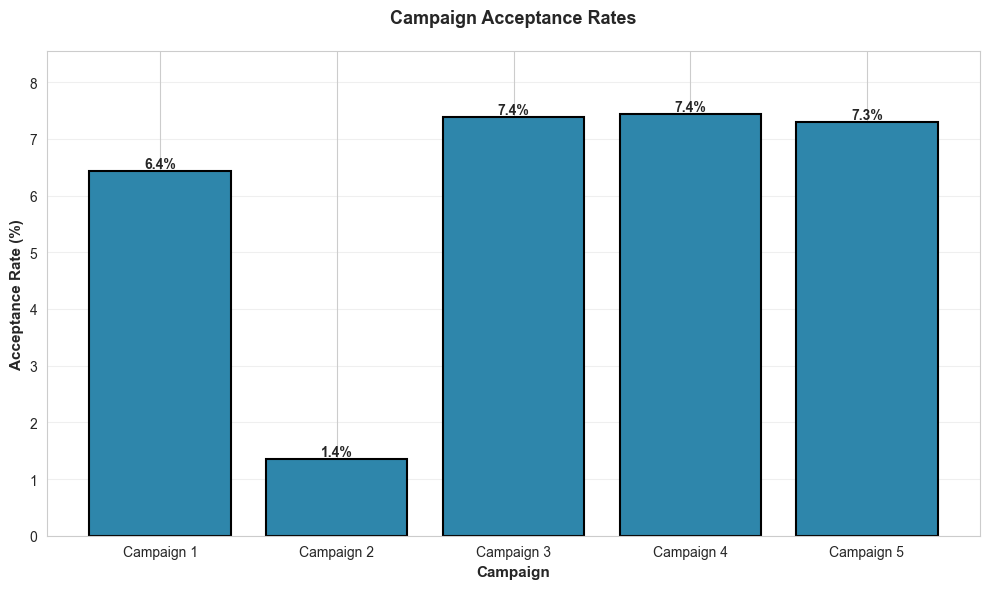

Campaign Acceptance Rates:
  Campaign 1: 6.44%
  Campaign 2: 1.36%
  Campaign 3: 7.39%
  Campaign 4: 7.44%
  Campaign 5: 7.30%

Overall Acceptance Rate: 5.99%


In [29]:
# Calculate acceptance rate for each campaign
campaign_names = ['Campaign 1', 'Campaign 2', 'Campaign 3', 'Campaign 4', 'Campaign 5']
campaign_cols_rate = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

acceptance_rates = [(df_enriched[col].sum() / len(df_enriched)) * 100 for col in campaign_cols_rate]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors_campaign = ['#2E86AB' if rate < 15 else '#A23B72' for rate in acceptance_rates]
bars = ax.bar(campaign_names, acceptance_rates, color=colors_campaign, edgecolor='black', linewidth=1.5)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Campaign', fontsize=11, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)', fontsize=11, fontweight='bold')
ax.set_title('Campaign Acceptance Rates', fontsize=13, fontweight='bold', pad=20)
ax.set_ylim(0, max(acceptance_rates) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/06_campaign_acceptance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Campaign Acceptance Rates:")
for name, rate in zip(campaign_names, acceptance_rates):
    print(f"  {name}: {rate:.2f}%")

overall_rate = (df_enriched['Total_Campaigns_Accepted'].sum() / (len(df_enriched) * 5)) * 100
print(f"\nOverall Acceptance Rate: {overall_rate:.2f}%")

### 1.6.7 Purchase Channel Comparison

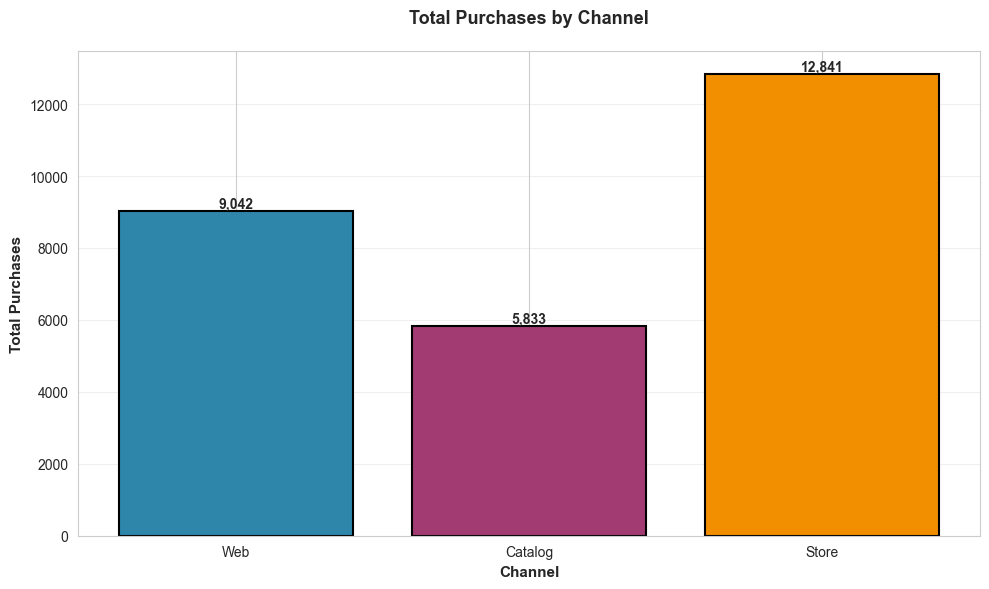

Purchase Channel Comparison:
  Web: 9,042 purchases (32.6%)
  Catalog: 5,833 purchases (21.0%)
  Store: 12,841 purchases (46.3%)


In [30]:
# Calculate total purchases by channel
channels = ['Web', 'Catalog', 'Store']
channel_purchases = [
    df_enriched['NumWebPurchases'].sum(),
    df_enriched['NumCatalogPurchases'].sum(),
    df_enriched['NumStorePurchases'].sum()
]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors_channel = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax.bar(channels, channel_purchases, color=colors_channel, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Channel', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Purchases', fontsize=11, fontweight='bold')
ax.set_title('Total Purchases by Channel', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/07_channel_usage.png', dpi=300, bbox_inches='tight')
plt.show()

print("Purchase Channel Comparison:")
total_purchases = sum(channel_purchases)
for channel, purchases in zip(channels, channel_purchases):
    pct = (purchases / total_purchases) * 100
    print(f"  {channel}: {purchases:,} purchases ({pct:.1f}%)")

### 1.6.8 Income vs Total Spending

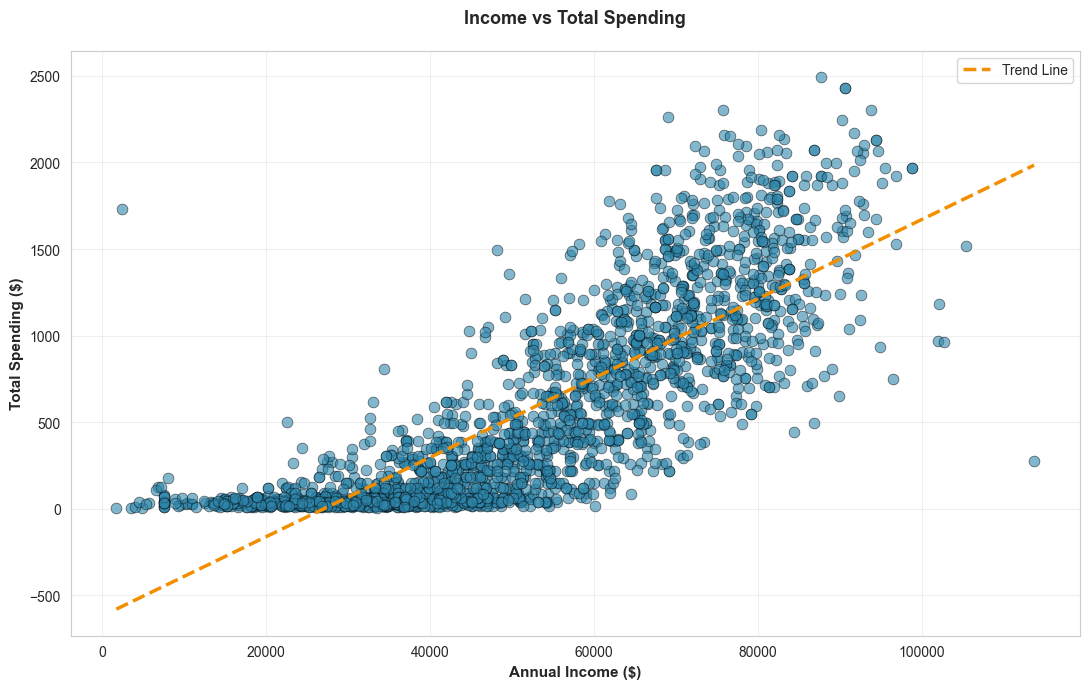

Correlation between Income and Total Spending: 0.823


In [31]:
# Create scatter plot of income vs total spending
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(df_enriched['Income'], df_enriched['MntTotal'],
          alpha=0.6, s=60, color='#2E86AB', edgecolor='black', linewidth=0.5)

# Add trend line
z = np.polyfit(df_enriched['Income'].dropna(), df_enriched.loc[df_enriched['Income'].notna(), 'MntTotal'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_enriched['Income'].min(), df_enriched['Income'].max(), 100)
ax.plot(x_trend, p(x_trend), color='#F18F01', linestyle='--', linewidth=2.5, label='Trend Line')

ax.set_xlabel('Annual Income ($)', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Spending ($)', fontsize=11, fontweight='bold')
ax.set_title('Income vs Total Spending', fontsize=13, fontweight='bold', pad=20)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/08_income_vs_spending.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate correlation
correlation = df_enriched['Income'].corr(df_enriched['MntTotal'])
print(f"Correlation between Income and Total Spending: {correlation:.3f}")

### 1.6.9 Total Spending by Number of Children

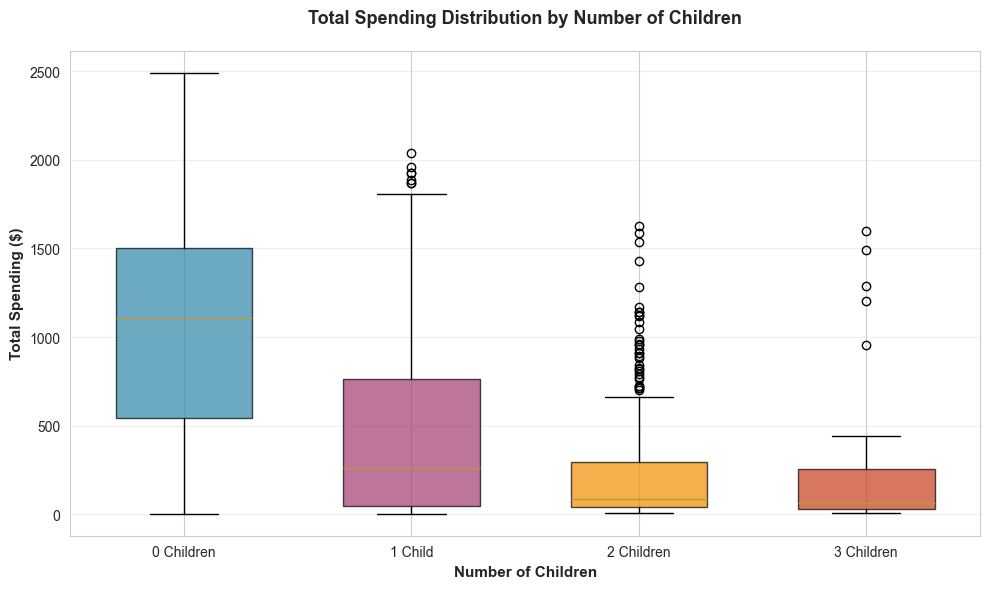

Spending by Number of Children:
  0 Children: Mean = $1,041, Median = $1,106, Count = 628
  1 Children: Mean = $435, Median = $264, Count = 1112
  2 Children: Mean = $222, Median = $84, Count = 415
  3 Children: Mean = $237, Median = $62, Count = 50


In [32]:
# Create box plot of spending by number of children
fig, ax = plt.subplots(figsize=(10, 6))

children_groups = sorted(df_enriched['Children'].unique())

box_plot = ax.boxplot([df_enriched[df_enriched['Children'] == n]['MntTotal'] for n in children_groups],
                       labels=[f'{int(n)} Child' if n == 1 else f'{int(n)} Children' for n in children_groups],
                       patch_artist=True,
                       widths=0.6)

# Color the boxes
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
for patch, color in zip(box_plot['boxes'], colors[:len(box_plot['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Number of Children', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Spending ($)', fontsize=11, fontweight='bold')
ax.set_title('Total Spending Distribution by Number of Children', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/09_spending_by_children.png', dpi=300, bbox_inches='tight')
plt.show()

print("Spending by Number of Children:")
for n in children_groups:
    spending = df_enriched[df_enriched['Children'] == n]['MntTotal']
    print(f"  {int(n)} Children: Mean = ${spending.mean():,.0f}, Median = ${spending.median():,.0f}, Count = {len(spending)}")

### 1.6.10 Web Visits vs Web Purchases

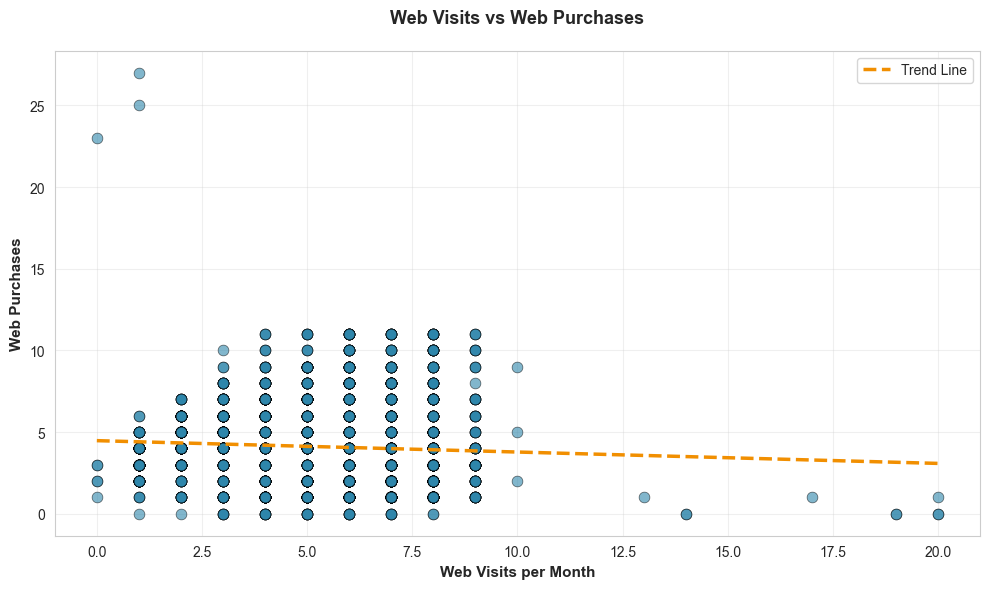

Correlation between Web Visits and Web Purchases: -0.061

Web Visit Statistics:
  Mean: 5.3 visits/month
  Median: 6.0 visits/month


In [33]:
# Create scatter plot of web visits vs web purchases
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_enriched['NumWebVisitsMonth'], df_enriched['NumWebPurchases'],
          alpha=0.6, s=60, color='#2E86AB', edgecolor='black', linewidth=0.5)

# Add trend line
z = np.polyfit(df_enriched['NumWebVisitsMonth'], df_enriched['NumWebPurchases'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_enriched['NumWebVisitsMonth'].min(), df_enriched['NumWebVisitsMonth'].max(), 100)
ax.plot(x_trend, p(x_trend), color='#F18F01', linestyle='--', linewidth=2.5, label='Trend Line')

ax.set_xlabel('Web Visits per Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Web Purchases', fontsize=11, fontweight='bold')
ax.set_title('Web Visits vs Web Purchases', fontsize=13, fontweight='bold', pad=20)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/10_web_visits_vs_purchases.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate correlation
correlation = df_enriched['NumWebVisitsMonth'].corr(df_enriched['NumWebPurchases'])
print(f"Correlation between Web Visits and Web Purchases: {correlation:.3f}")
print(f"\nWeb Visit Statistics:")
print(f"  Mean: {df_enriched['NumWebVisitsMonth'].mean():.1f} visits/month")
print(f"  Median: {df_enriched['NumWebVisitsMonth'].median():.1f} visits/month")

## 1.7 Save Enriched Data

In [34]:
# Save the enriched dataset with engineered features
output_path = '../data/processed/marketing_cleaned.csv'
df_enriched.to_csv(output_path, index=False)

print(f"Enriched dataset saved to: {output_path}")
print(f"\nFinal dataset shape: {df_enriched.shape}")
print(f"Total columns: {len(df_enriched.columns)}")
print(f"Memory usage: {df_enriched.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Enriched dataset saved to: ../data/processed/marketing_cleaned.csv

Final dataset shape: (2205, 44)
Total columns: 44
Memory usage: 0.84 MB


## 1.8 Key Observations

### Data Quality
- **Clean Dataset:** The input dataset contains no missing values and is well-prepared for analysis
- **2,205 customers** with **39 columns** of pre-engineered features
- Education and marital status are already one-hot encoded

### Income & Spending Insights
- Income shows strong positive correlation with total spending
- Spending varies significantly by education level with higher education correlating to higher spending
- Top spending categories are wines, meat products, and gold

### Customer Engagement Insights
- Campaign acceptance rates vary across the 5 campaigns
- Store purchases dominate, followed by web and catalog channels
- Lower correlation between web visits and web purchases suggests other factors drive conversion

### Demographic Insights
- Age distribution is relatively balanced across the customer base
- Customers with fewer children tend to have higher spending
- Family composition is an important segmentation variable

### Feature Engineering
- Created 'Children' from Kidhome + Teenhome
- Calculated 'Total_Purchases' across all channels
- Derived 'Conversion_Rate' for campaign effectiveness analysis

---

**Next Steps:** Proceed to Notebook 2 for customer segmentation using clustering algorithms (K-Means, Hierarchical Clustering) to identify distinct customer groups for targeted marketing strategies.